# Wasserstein DRO for logistic classification

This notebook generates `fig:kantorovich-dro-ambiguity`. It illustrates Wasserstein distributionally robust optimization for a binary logistic classifier. For samples $(x_i,y_i)$ with fixed labels $y_i\in\{-1,+1\}$ and empirical law $\hat\alpha_n$, the robust risk is represented through the dual envelope

$$
    \sup_{\beta:\, W_2(\beta,\hat\alpha_n)\leq \rho}
    \int \ell_\theta(x,y)\,d\beta(x,y)
    =
    \inf_{\lambda\geq 0}
    \lambda\rho^2
    + \frac1n\sum_i
    \sup_x\{\ell_\theta(x,y_i)-\lambda\|x-x_i\|^2\},
$$

where only feature perturbations are charged. Since a linear logistic loss depends on $x$ through one scalar margin, the inner supremum is a one-dimensional maximization along the normal direction to the separating hyperplane.

The figure shows the same red/blue training cloud and the learned linear decision boundary for three radii: no robustness, a medium Wasserstein radius, and a larger radius. The violet strip shows the Euclidean $\rho$-neighborhood of the classifier boundary as a local geometric proxy for feature perturbations; the actual Wasserstein constraint remains a global average transport budget. The exported PDF panels contain no embedded titles; LaTeX supplies the panel labels and caption.


In [1]:
from pathlib import Path
import os
import shutil
import sys

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mpl-ot4ml")

ROOT = Path.cwd()
if (ROOT / "notebooks-figures" / "figure_style.py").exists():
    FIGROOT = ROOT / "notebooks-figures"
elif (ROOT / "figure_style.py").exists():
    FIGROOT = ROOT
    ROOT = FIGROOT.parent
elif (ROOT.parent / "notebooks-figures" / "figure_style.py").exists():
    ROOT = ROOT.parent
    FIGROOT = ROOT / "notebooks-figures"
else:
    raise RuntimeError("Could not locate figure_style.py")

sys.path.insert(0, str(FIGROOT.resolve()))

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap, to_rgba
from scipy.optimize import minimize, minimize_scalar

from figure_style import (
    BACKGROUND,
    BLUE,
    DIRAC_MARKER_SIZE,
    RED,
    VIOLET,
    figure_dir,
    remove_axes,
    save_pdf,
    setup_matplotlib,
)

setup_matplotlib()

NAME = "kantorovich-dro-ambiguity"
OUT = figure_dir(NAME)
ARXIV_OUT = ROOT / "arxiv" / "figures"
THUMB_OUT = FIGROOT / "thumbnails"
ARXIV_OUT.mkdir(parents=True, exist_ok=True)
THUMB_OUT.mkdir(parents=True, exist_ok=True)


## Data and Wasserstein-robust logistic fit

The point cloud is intentionally small and mildly overlapping. A nominal logistic classifier is fitted for $\rho=0$. For $\rho>0$, the objective uses the Wasserstein dual formula above. The optimization is deliberately low-dimensional: the classifier has parameters $(w,b)\in\mathbb R^2\times\mathbb R$, and the DRO dual adds only the scalar multiplier $\lambda$.


In [2]:
rng = np.random.default_rng(75)

blue_1 = rng.normal(size=(18, 2)) @ np.array([[0.26, 0.08], [0.00, 0.20]]) + np.array([-0.45, 0.17])
blue_2 = rng.normal(size=(8, 2)) @ np.array([[0.20, -0.04], [0.00, 0.16]]) + np.array([-0.05, -0.38])
red_1 = rng.normal(size=(18, 2)) @ np.array([[0.24, -0.07], [0.00, 0.21]]) + np.array([0.48, -0.02])
red_2 = rng.normal(size=(7, 2)) @ np.array([[0.20, 0.05], [0.00, 0.14]]) + np.array([0.07, 0.43])

blue_pts = np.vstack([blue_1, blue_2])
red_pts = np.vstack([red_1, red_2])
angle = -0.25
rotation = np.array([[np.cos(angle), -np.sin(angle)], [np.sin(angle), np.cos(angle)]])
blue_pts = blue_pts @ rotation.T
red_pts = red_pts @ rotation.T

X = np.vstack([blue_pts, red_pts])
y = np.r_[np.ones(len(blue_pts)), -np.ones(len(red_pts))]

ridge = 0.035
radii = [0.0, 0.10, 0.22]
panel_names = ["rho-zero", "rho-medium", "rho-large"]


def softplus(t):
    return np.logaddexp(0.0, t)


def nominal_objective(theta):
    w = theta[:2]
    b = theta[2]
    margins = y * (X @ w + b)
    return np.mean(softplus(-margins)) + ridge * np.dot(w, w)


def inner_w2_logistic_value(margin, norm_w, lam):
    """Compute sup_r log(1+exp(-(margin-norm_w*r))) - lam*r^2."""
    if norm_w < 1e-12:
        return softplus(-margin)
    upper = max(3.0, norm_w / max(lam, 1e-8) + abs(margin) / norm_w + 2.0)
    res = minimize_scalar(
        lambda r: -(softplus(norm_w * r - margin) - lam * r * r),
        bounds=(0.0, upper),
        method="bounded",
        options={"xatol": 1e-5, "maxiter": 60},
    )
    return -res.fun


def dro_objective(params, rho):
    w = params[:2]
    b = params[2]
    log_lam = np.clip(params[3], -30.0, 30.0)
    lam = float(np.exp(log_lam))
    norm_w = float(np.linalg.norm(w))
    margins = y * (X @ w + b)
    robust_terms = [inner_w2_logistic_value(m, norm_w, lam) for m in margins]
    return lam * rho**2 + np.mean(robust_terms) + ridge * np.dot(w, w)


nominal = minimize(nominal_objective, np.array([-1.0, 0.0, 0.0]), method="BFGS")
solutions = []
solutions.append({"rho": radii[0], "theta": nominal.x, "objective": nominal.fun, "lambda": np.inf})

warm = np.r_[nominal.x, np.log(10.0)]
for rho in radii[1:]:
    coarse = minimize(
        lambda p: dro_objective(p, rho),
        warm,
        method="Nelder-Mead",
        options={"maxiter": 700, "xatol": 1e-5, "fatol": 1e-5},
    )
    polish = minimize(
        lambda p: dro_objective(p, rho),
        coarse.x,
        method="BFGS",
        options={"maxiter": 80},
    )
    best = polish if polish.fun <= coarse.fun else coarse
    warm = best.x
    solutions.append({
        "rho": rho,
        "theta": best.x[:3],
        "objective": float(best.fun),
        "lambda": float(np.exp(np.clip(best.x[3], -30.0, 30.0))),
    })

for sol in solutions:
    w = sol["theta"][:2]
    b = sol["theta"][2]
    print(
        f"rho={sol['rho']:.2f}, objective={sol['objective']:.4f}, "
        f"||w||={np.linalg.norm(w):.3f}, b={b:.3f}, lambda={sol['lambda']:.3g}"
    )


rho=0.00, objective=0.5689, ||w||=1.542, b=0.101, lambda=inf
rho=0.10, objective=0.6257, ||w||=1.193, b=0.085, lambda=2.62
rho=0.22, objective=0.6766, ||w||=0.617, b=0.062, lambda=0.68


## Drawing utilities

The red and blue points are fixed across panels. The faint background shows the logistic score; the black line is the zero level set $w_\rho^\top x+b_\rho=0$. For $\rho>0$, the violet tube is the Euclidean $\rho$-neighborhood of this boundary. It is a local visual proxy for which samples can be crossed by perturbations of size $\rho$; the true $W_2$ constraint is global and averages squared displacement over the empirical law.


In [3]:
all_points = np.vstack([X])
margin = 0.22
xlim = (all_points[:, 0].min() - margin, all_points[:, 0].max() + margin)
ylim = (all_points[:, 1].min() - margin, all_points[:, 1].max() + margin)
xlim = (min(xlim[0], -1.04), max(xlim[1], 1.04))
ylim = (min(ylim[0], -0.78), max(ylim[1], 0.78))

grid_x = np.linspace(xlim[0], xlim[1], 260)
grid_y = np.linspace(ylim[0], ylim[1], 260)
GX, GY = np.meshgrid(grid_x, grid_y)
GRID = np.column_stack([GX.ravel(), GY.ravel()])
score_cmap = LinearSegmentedColormap.from_list("score_red_white_blue", [to_rgba(RED, 0.95), (1, 1, 1, 1), to_rgba(BLUE, 0.95)])


def sigmoid(t):
    return 1.0 / (1.0 + np.exp(-np.clip(t, -40.0, 40.0)))


def draw_boundary(ax, theta, rho):
    w = theta[:2]
    b = theta[2]
    norm_w = max(np.linalg.norm(w), 1e-12)
    score = (GRID @ w + b).reshape(GX.shape)
    distance = score / norm_w
    probability_blue = sigmoid(score)

    ax.imshow(
        probability_blue,
        extent=(xlim[0], xlim[1], ylim[0], ylim[1]),
        origin="lower",
        cmap=score_cmap,
        vmin=0.0,
        vmax=1.0,
        alpha=0.18,
        interpolation="bilinear",
        zorder=0,
    )
    if rho > 1e-12:
        ax.contourf(
            GX,
            GY,
            np.abs(distance),
            levels=[0.0, rho],
            colors=[VIOLET],
            alpha=0.13,
            zorder=1,
        )
        ax.contour(
            GX,
            GY,
            distance,
            levels=[-rho, rho],
            colors=[VIOLET],
            linewidths=0.58,
            linestyles=[(0, (2.0, 2.0)), (0, (2.0, 2.0))],
            alpha=0.68,
            zorder=3,
        )
    ax.contour(GX, GY, score, levels=[0.0], colors=["#202020"], linewidths=1.25, zorder=5)


def draw_points(ax):
    ax.scatter(red_pts[:, 0], red_pts[:, 1], s=DIRAC_MARKER_SIZE * 0.78, color=RED, edgecolor="none", zorder=7)
    ax.scatter(blue_pts[:, 0], blue_pts[:, 1], s=DIRAC_MARKER_SIZE * 0.78, color=BLUE, edgecolor="none", zorder=7)


def draw_panel(solution, path):
    fig, ax = plt.subplots(figsize=(2.25, 2.05))
    ax.set_facecolor(BACKGROUND)
    draw_boundary(ax, solution["theta"], solution["rho"])
    draw_points(ax)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")
    remove_axes(ax)
    save_pdf(fig, path, pad_inches=0.035)
    plt.close(fig)

for name, sol in zip(panel_names, solutions):
    draw_panel(sol, OUT / f"{name}.pdf")
    shutil.copyfile(OUT / f"{name}.pdf", ARXIV_OUT / f"{NAME}--{name}.pdf")


## Thumbnail

The thumbnail is a compact raster contact sheet of the three exported panels. It is used by the searchable figure gallery and by GitHub's notebook preview.


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.25))
for ax, sol in zip(axes, solutions):
    ax.set_facecolor(BACKGROUND)
    draw_boundary(ax, sol["theta"], sol["rho"])
    draw_points(ax)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")
    remove_axes(ax)
fig.subplots_adjust(left=0.01, right=0.99, bottom=0.02, top=0.98, wspace=0.05)
thumb_path = THUMB_OUT / f"{NAME}.png"
fig.savefig(thumb_path, dpi=190, bbox_inches="tight", pad_inches=0.015)
plt.close(fig)


## Figure preview

The output below embeds the generated thumbnail so the notebook renders directly on GitHub.


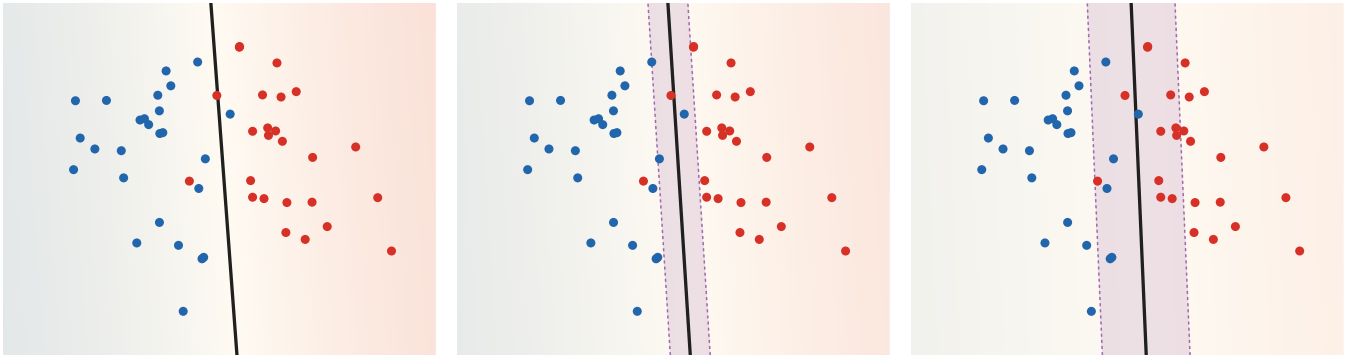

In [5]:
from IPython.display import Image, display

preview = THUMB_OUT / f"{NAME}.png"
display(Image(filename=str(preview)))
